In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report,recall_score,precision_score
from gensim.models import KeyedVectors  # Gensim for Word2Vec
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [ ]:
pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.0 MB/s eta 0:00:00


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [ ]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [29]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/TA DIAZ/datasetfix_cleaned.csv', encoding='latin1', sep=',')
df = df.dropna(subset=['Tweet', 'HS'])
df


,Tweet,HS,tokenized_text
0,cowok usaha lacak perhati gue loe lantas remeh...,1,"['cowok', 'usaha', 'lacak', 'perhati', 'gue', ..."
1,telat ngasih eluedan sarap gue gaul cigax jifl...,0,"['telat', 'ngasih', 'eluedan', 'sarap', 'gue',..."
2,kadang berfikir percaya tuhan jatuh berkalikal...,0,"['kadang', 'berfikir', 'percaya', 'tuhan', 'ja..."
3,akunnku mata sipit liat,0,"['akunnku', 'mata', 'sipit', 'liat']"
4,kaum cebong kapir udah liat dongok dongok hahahah,1,"['kaum', 'cebong', 'kapir', 'udah', 'liat', 'd..."
...,...,...,...
13010,ngomong ndasmu congor yg kate anjyng,1,"['ngomong', 'ndasmu', 'congor', 'yg', 'kate', ..."
13011,kasur enak kunyuk,0,"['kasur', 'enak', 'kunyuk']"
13012,hati hati bisu gnnlagi bosan huft,0,"['hati', 'hati', 'bisu', 'gnnlagi', 'bosan', '..."
13013,bom real mudah deteksi bom kubur dahsyat ledak...,0,"['bom', 'real', 'mudah', 'deteksi', 'bom', 'ku..."


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load your Word2Vec model from the .bin file
model_word2vec = KeyedVectors.load_word2vec_format('/content/drive/MyDrive/TA DIAZ/ws_model300.bin', binary=True)

Text(0, 0.5, 'Total Data')

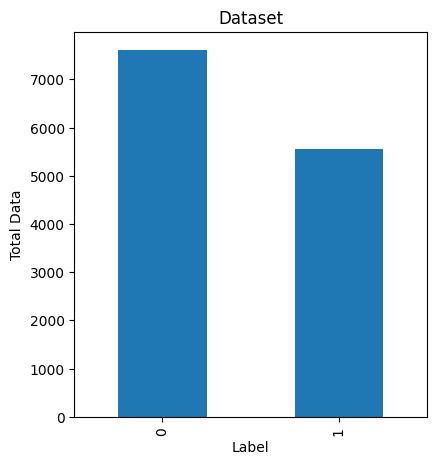

In [ ]:
# Visualisasi data sebelum preprocessing
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Dataset')
df['HS'].value_counts().plot(kind='bar')
plt.xlabel('Label')
plt.ylabel('Total Data')

In [ ]:
kamus = []

def clean_text(text):
  for i in range(0,31962) :
    # Remove mentions
    text = re.sub(r'@[A-Za-z0-9_]+', '', str(text))
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Convert to lowercase
    text = text.lower()
    # Hapus emoticon (dalam contoh ini hanya menghapus emoticon tertentu, Anda dapat menambahkan lebih banyak)
    text = re.sub(':-\)', '', text)
    text = re.sub(':\)', '', text)
    # Remove whitespace
    text = text.strip()
    kamus.append(text)
    return text

df['clean_text'] = df['Tweet'].apply(clean_text)
df['Tweet']=df['clean_text']
df = df[['Tweet','HS']]
df.head()

,Tweet,HS
0,saat cowok usaha lacak perhati gue loe lantas ...,1
1,rt user user telat ngasih eluedan sarap gue ga...,0
2,kadang berfikir percaya tuhan jatuh berkalikal...,0
3,user user akunnku mata sipit liat,0
4,user user kaum cebong kapir udah liat dongok d...,1


In [ ]:
def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token.lower() not in stop_words]
    return ' '.join(filtered_tokens)

In [ ]:
# get stopword indonesia
list_stopwords = stopwords.words('indonesian')

# Load Indonesian stopwords
stop_words = stopwords.words('indonesian')
# # ---------------------------- manualy add stopword  ------------------------------------
# # append additional stopword
stop_words.extend(["ª", "ðŸ˜", "ƒðŸ˜", "dgn", "ny", "d", 'klo', 'lu', 'ðŸ','ðŸ',
                       'rt', 'ðŸ™', 'biar', 'bikin', 'user',
                       'gak', 'ga', 'krn', 'nya', 'nih', 'sih',
                       'si', 'tau', 'ðŸ¥²', 'tuh', 'ðŸ¥¹', 'ya', 'âœ',
                       'jd', 'ðŸ¤¯', 'sdh', 'aja', '...', 'ŠðŸ˜', ' ðŸ«¶', 'ðŸ¤©',
                       'ðŸ•', 'hehe', 'pen', 'u', '½ðŸ†', 'loh', 'ðŸ',
                       'ðŸ—¿ðŸ¤', 'yah', 'gtgt','Œ', 'tik', 'tok', 'kayk', 'USER', '¤©', ' ðŸ§¬','ðŸ«', 'ðŸ§', '¼', 'ºï','‰', 'lol', 'xfxfxx','rt user' ])


In [ ]:
# Add stopwords from txt file
txt_stopword = pd.read_csv("/content/drive/MyDrive/TA DIAZ/stopword bahasa.txt", names=["stopwords"], header=None)
stop_words.extend(txt_stopword["stopwords"][0].split(' '))

In [ ]:
# Convert list to set for faster processing
stop_words = set(stop_words)

df['remove_stopwords'] = df['Tweet'].apply(remove_stopwords)
df['Tweet'] = df['remove_stopwords']
df = df[['Tweet', 'HS']]
df.head()


,Tweet,HS
0,cowok usaha lacak perhati gue loe lantas remeh...,1
1,telat ngasih eluedan sarap gue gaul cigax jifl...,0
2,kadang berfikir percaya tuhan jatuh berkalikal...,0
3,akunnku mata sipit liat,0
4,kaum cebong kapir udah liat dongok dongok hahahah,1


In [ ]:
# Stemming
stemmer = StemmerFactory().create_stemmer()

def stem_text(text):
    words = word_tokenize(text)
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

df['stemmed_text'] = df['Tweet'].apply(stem_text)
df['Tweet'] = df['stemmed_text']
df = df[['Tweet', 'HS']]
df.head()

,Tweet,HS
0,saat cowok usaha lacak perhati gue loe lantas ...,1
1,rt user user telat ngasih eluedan sarap gue ga...,0
2,kadang berfikir percaya tuhan jatuh berkalikal...,0
3,user user akunnku mata sipit liat,0
4,user user kaum cebong kapir udah liat dongok d...,1


In [ ]:
# Tokenization
def tokenize_text(text):
    return word_tokenize(text)

df['tokenized_text'] = df['Tweet'].apply(tokenize_text)
df.head()

,Tweet,HS,tokenized_text
0,cowok usaha lacak perhati gue loe lantas remeh...,1,"[cowok, usaha, lacak, perhati, gue, loe, lanta..."
1,telat ngasih eluedan sarap gue gaul cigax jifl...,0,"[telat, ngasih, eluedan, sarap, gue, gaul, cig..."
2,kadang berfikir percaya tuhan jatuh berkalikal...,0,"[kadang, berfikir, percaya, tuhan, jatuh, berk..."
3,akunnku mata sipit liat,0,"[akunnku, mata, sipit, liat]"
4,kaum cebong kapir udah liat dongok dongok hahahah,1,"[kaum, cebong, kapir, udah, liat, dongok, dong..."


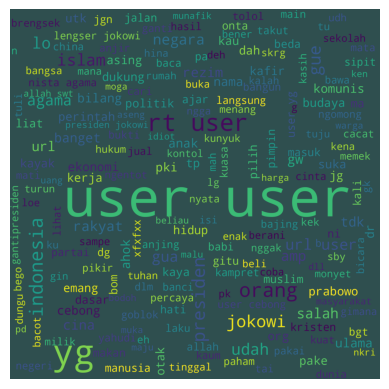

In [ ]:
#code wordcloud

from wordcloud import WordCloud, STOPWORDS

all_words = " ".join(kamus)



wordcloud = WordCloud(height=2000, width=2000, stopwords=STOPWORDS, background_color='darkslategrey')
wordcloud = wordcloud.generate(all_words)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

Text(0, 0.5, 'Jumlah Data')

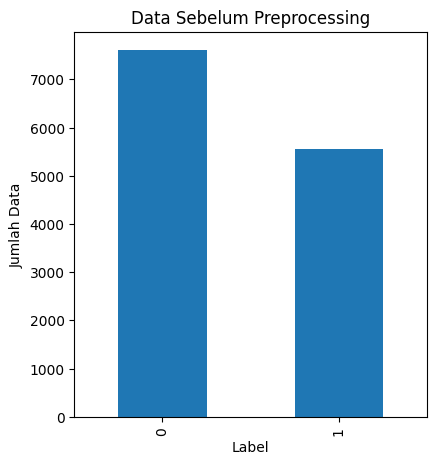

In [ ]:
# Visualisasi data sebelum preprocessing
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Data Sebelum Preprocessing')
df['HS'].value_counts().plot(kind='bar')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')

In [ ]:
# Menggunakan shape untuk melihat jumlah baris (data) dan kolom dalam DataFrame
jumlah_data = df.shape[0]  # Ini akan mengambil jumlah baris, yang merepresentasikan jumlah data

print("Jumlah data dalam dataset:", jumlah_data)

Jumlah data dalam dataset: 13167


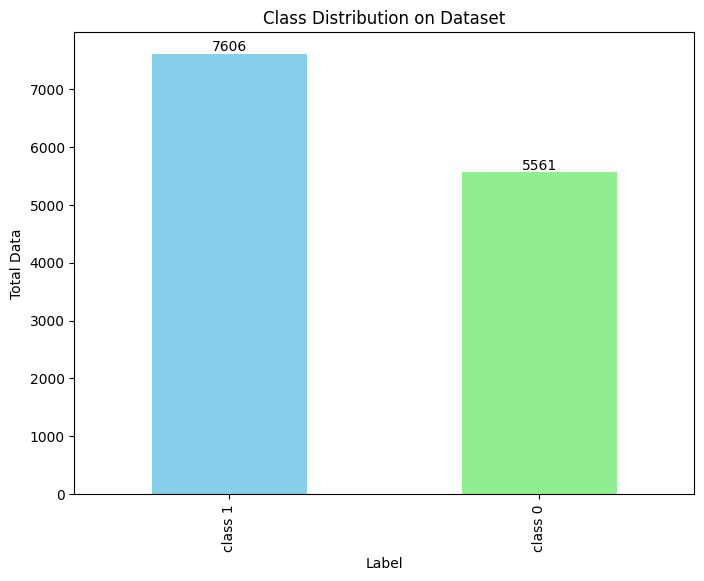

In [ ]:
# Visualisasi distribusi kelas pada dataset
plt.figure(figsize=(8, 6))
plt.title('Class Distribution on Dataset')
counts = df['HS'].value_counts()
counts.plot(kind='bar', color=['skyblue', 'lightgreen'])
plt.xlabel('Label')
plt.ylabel('Total Data')

# Menambahkan label jumlah data di atas setiap bar
for i, count in enumerate(counts):
    plt.text(i, count, str(count), ha='center', va='bottom')

plt.xticks([0, 1], ['class 1', 'class 0'])
plt.show()


In [ ]:
# Simpan dataframe ke file CSV di Google Colab
output_file = '/content/blank.csv'
df.to_csv(output_file, index=False)  # Menyimpan file tanpa menyertakan index

# Mendownload file menggunakan library files dari Google Colab
from google.colab import files
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>